In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

from torchvision import transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights

# =========================
# 1. Reproducibility
# =========================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =========================
# 2. Paths
# =========================
TRAIN_DIR = "/kaggle/input/datasets/jubayerhasan755/alzheimer-dataset02/alzheimer/train"
TEST_DIR  = "/kaggle/input/datasets/jubayerhasan755/alzheimer-dataset02/alzheimer/test"

# =========================
# 3. Set ratio for THIS notebook
# Change this in each notebook
# =========================
TRAIN_PERCENT = 90
TEST_PERCENT = 10

assert TRAIN_PERCENT + TEST_PERCENT == 100
print(f"Running ViT experiment for split: {TRAIN_PERCENT}:{TEST_PERCENT}")

# =========================
# 4. Collect image paths
# =========================
IMG_EXTENSIONS = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff")

LABEL_MAP = {
    "AD": "AD",
    "MCI": "MCI",
    "CN": "CN"
}

def normalize_label(folder_name):
    return LABEL_MAP.get(folder_name, folder_name)

def collect_images_from_root(root_dir):
    rows = []
    class_folders = sorted([
        d for d in os.listdir(root_dir)
        if os.path.isdir(os.path.join(root_dir, d))
    ])

    for class_name in class_folders:
        class_path = os.path.join(root_dir, class_name)
        image_files = []

        for ext in IMG_EXTENSIONS:
            image_files.extend(glob.glob(os.path.join(class_path, ext)))

        normalized_label = normalize_label(class_name)

        for img_path in image_files:
            rows.append({
                "filepath": img_path,
                "label": normalized_label,
                "source_folder": os.path.basename(root_dir)
            })

    return pd.DataFrame(rows)

train_df = collect_images_from_root(TRAIN_DIR)
test_df  = collect_images_from_root(TEST_DIR)

full_df = pd.concat([train_df, test_df], ignore_index=True)
full_df = full_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Total images:", len(full_df))
print("\nClass distribution:")
print(full_df["label"].value_counts())
print("\nUnique labels:", full_df["label"].unique())

# =========================
# 5. Create split
# =========================
test_size = TEST_PERCENT / 100.0

train_val_df, test_split_df = train_test_split(
    full_df,
    test_size=test_size,
    stratify=full_df["label"],
    random_state=42
)

train_split_df, val_split_df = train_test_split(
    train_val_df,
    test_size=0.10,
    stratify=train_val_df["label"],
    random_state=42
)

print(f"\n===== Split {TRAIN_PERCENT}:{TEST_PERCENT} =====")
print(f"Train samples: {len(train_split_df)}")
print(train_split_df["label"].value_counts())

print(f"\nValidation samples: {len(val_split_df)}")
print(val_split_df["label"].value_counts())

print(f"\nTest samples: {len(test_split_df)}")
print(test_split_df["label"].value_counts())

# =========================
# 6. Save split CSVs
# =========================
OUTPUT_DIR = f"/kaggle/working/vit_split_{TRAIN_PERCENT}_{TEST_PERCENT}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_split_df.to_csv(os.path.join(OUTPUT_DIR, "train.csv"), index=False)
val_split_df.to_csv(os.path.join(OUTPUT_DIR, "val.csv"), index=False)
test_split_df.to_csv(os.path.join(OUTPUT_DIR, "test.csv"), index=False)

print("\nSplit CSV files saved to:", OUTPUT_DIR)

# =========================
# 7. Label mapping
# =========================
label_to_idx = {
    "AD": 0,
    "MCI": 1,
    "CN": 2
}

idx_to_label = {v: k for k, v in label_to_idx.items()}
print("\nLabel mapping:", label_to_idx)

# =========================
# 8. Dataset class
# =========================
class AlzheimerDataset(Dataset):
    def __init__(self, dataframe, transform=None, label_map=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.label_map = label_map

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = row["filepath"]
        label_name = row["label"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.label_map[label_name]
        return image, label

# =========================
# 9. Transforms
# =========================
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =========================
# 10. Datasets
# =========================
train_dataset = AlzheimerDataset(train_split_df, transform=train_transform, label_map=label_to_idx)
val_dataset   = AlzheimerDataset(val_split_df,   transform=val_test_transform, label_map=label_to_idx)
test_dataset  = AlzheimerDataset(test_split_df,  transform=val_test_transform, label_map=label_to_idx)

print("\nTrain samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

# =========================
# 11. DataLoaders
# =========================
BATCH_SIZE = 16
NUM_WORKERS = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("\nTrain batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

# =========================
# 12. Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nUsing device:", device)

# =========================
# 13. Load pretrained ViT-B/16
# =========================
weights = ViT_B_16_Weights.DEFAULT
model = vit_b_16(weights=weights)

# Replace classifier head for 3 classes
in_features = model.heads.head.in_features
model.heads.head = nn.Linear(in_features, 3)

# Fine-tune full model
for param in model.parameters():
    param.requires_grad = True

model = model.to(device)
print("\nViT model ready.")

# =========================
# 14. Compute class weights
# =========================
class_counts = train_split_df["label"].value_counts()
print("\nTrain class counts:")
print(class_counts)

counts = np.array([
    class_counts["AD"],
    class_counts["MCI"],
    class_counts["CN"]
], dtype=np.float32)

class_weights = counts.sum() / (len(counts) * counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("\nClass weights:", class_weights)

# =========================
# 15. Loss and optimizer
# =========================
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("\nLoss and optimizer initialized.")

# =========================
# 16. Sanity check
# =========================
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("\nSanity Check:")
print("Input batch shape :", images.shape)
print("Label batch shape :", labels.shape)
print("Output batch shape:", outputs.shape)

Running ViT experiment for split: 90:10
Total images: 5154

Class distribution:
label
MCI    2590
CN     1440
AD     1124
Name: count, dtype: int64

Unique labels: ['CN' 'AD' 'MCI']

===== Split 90:10 =====
Train samples: 4174
label
MCI    2098
CN     1166
AD      910
Name: count, dtype: int64

Validation samples: 464
label
MCI    233
CN     130
AD     101
Name: count, dtype: int64

Test samples: 516
label
MCI    259
CN     144
AD     113
Name: count, dtype: int64

Split CSV files saved to: /kaggle/working/vit_split_90_10

Label mapping: {'AD': 0, 'MCI': 1, 'CN': 2}

Train samples: 4174
Val samples: 464
Test samples: 516

Train batches: 261
Val batches: 29
Test batches: 33

Using device: cuda
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 216MB/s] 



ViT model ready.

Train class counts:
label
MCI    2098
CN     1166
AD      910
Name: count, dtype: int64

Class weights: tensor([1.5289, 0.6632, 1.1933], device='cuda:0')

Loss and optimizer initialized.

Sanity Check:
Input batch shape : torch.Size([16, 3, 224, 224])
Label batch shape : torch.Size([16])
Output batch shape: torch.Size([16, 3])


Results will be saved to: /kaggle/working/vit_results_90_10
Epoch [1/50] | Train Loss: 1.1273 | Train Acc: 0.3476 | Val Loss: 1.0952 | Val Acc: 0.5065 | Time: 156.01s
 Best model saved at epoch 1 with val_acc=0.5065
Epoch [2/50] | Train Loss: 1.0826 | Train Acc: 0.4109 | Val Loss: 1.0629 | Val Acc: 0.3147 | Time: 175.18s
Epoch [3/50] | Train Loss: 1.0710 | Train Acc: 0.4185 | Val Loss: 1.0365 | Val Acc: 0.4978 | Time: 175.71s
Epoch [4/50] | Train Loss: 1.0552 | Train Acc: 0.4506 | Val Loss: 1.0704 | Val Acc: 0.3341 | Time: 176.05s
Epoch [5/50] | Train Loss: 1.0387 | Train Acc: 0.4648 | Val Loss: 1.0762 | Val Acc: 0.4310 | Time: 175.89s
Epoch [6/50] | Train Loss: 1.0126 | Train Acc: 0.4873 | Val Loss: 1.0398 | Val Acc: 0.4698 | Time: 175.53s
Epoch [7/50] | Train Loss: 0.9833 | Train Acc: 0.5069 | Val Loss: 0.9886 | Val Acc: 0.5388 | Time: 176.16s
 Best model saved at epoch 7 with val_acc=0.5388
Epoch [8/50] | Train Loss: 0.9491 | Train Acc: 0.5278 | Val Loss: 0.9153 | Val Acc: 0.4547 | 

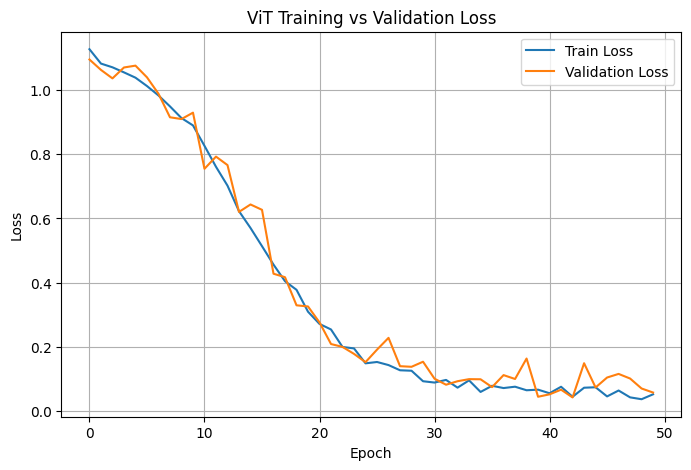

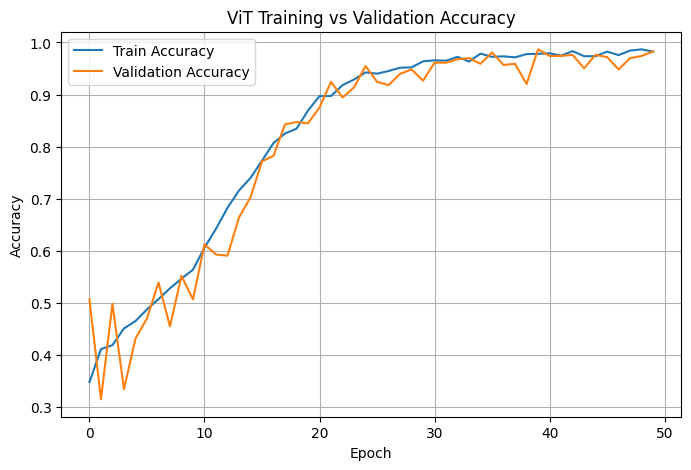


Step 2 complete: ViT training finished successfully.


In [2]:
# =========================
# ViT Step 2: Training + validation + best model saving
# =========================

import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import torch

# =========================
# 1. Training settings
# =========================
NUM_EPOCHS = 50
PATIENCE = 50   # keeps training through all 50 epochs
SAVE_DIR = f"/kaggle/working/vit_results_{TRAIN_PERCENT}_{TEST_PERCENT}"
os.makedirs(SAVE_DIR, exist_ok=True)

best_model_path = os.path.join(SAVE_DIR, "best_vit_b16.pth")

print("Results will be saved to:", SAVE_DIR)

# =========================
# 2. Helper functions
# =========================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_correct / total_samples

    return epoch_loss, epoch_acc


def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            running_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_correct / total_samples

    return epoch_loss, epoch_acc

# =========================
# 3. History containers
# =========================
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_acc = 0.0
best_epoch = 0
epochs_without_improvement = 0

# =========================
# 4. Training loop
# =========================
start_training_time = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    epoch_time = time.time() - epoch_start_time

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"Time: {epoch_time:.2f}s")

    # Save best model based on validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        epochs_without_improvement = 0

        torch.save(model.state_dict(), best_model_path)
        print(f" Best model saved at epoch {best_epoch} with val_acc={best_val_acc:.4f}")
    else:
        epochs_without_improvement += 1

    # Early stopping check
    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping triggered after {epoch+1} epochs.")
        break

total_training_time = time.time() - start_training_time

print("\nTraining complete.")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Best Epoch: {best_epoch}")
print(f"Total Training Time: {total_training_time:.2f} seconds")
print(f"Best model saved to: {best_model_path}")

# =========================
# 5. Load best model
# =========================
model.load_state_dict(torch.load(best_model_path))
model = model.to(device)
model.eval()

print("Best ViT model loaded for final evaluation.")

# =========================
# 6. Save training history
# =========================
history_df = pd.DataFrame({
    "epoch": list(range(1, len(history["train_loss"]) + 1)),
    "train_loss": history["train_loss"],
    "val_loss": history["val_loss"],
    "train_acc": history["train_acc"],
    "val_acc": history["val_acc"]
})

history_csv_path = os.path.join(SAVE_DIR, "training_history.csv")
history_df.to_csv(history_csv_path, index=False)

print("Training history saved to:", history_csv_path)

# =========================
# 7. Plot and save loss curve
# =========================
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ViT Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "loss_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 8. Plot and save accuracy curve
# =========================
plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ViT Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "accuracy_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

print("\nStep 2 complete: ViT training finished successfully.")